# Векторные модели. Word2Vec

+ Firth (1957:11):
You shall know a word by the company it keeps . . .

+ Дистрибутивная гипотеза: значение слова определяется его контекстом — иначе говоря, словами, которые встречаются рядом с этим словом в тексте.

+ Область лингвистики, которая занимается вычислением степени семантической близости между словами/текстами и т.п. на основании их распределения (дистрибуции) в больших массивах данных (текстовых корпусах) назвается **дистрибутивной семантикой**.

## Кратко о существующих системах

**GloVe**

GloVe берет и строит полную матрицу совместной встречаемости и после этого с помощью алгоритмов уменьшения размерности преобразует ее так, чтобы вектора были опредленной длины


**Word2Vec**

Это уже нейросеть и она на основе корпуса постепенно подбирает коэффициенты (значения в векторах) для каждого слова так, чтобы с помощью них можно было наилучшим образом предсказывать слова по контексту

**FastText**

Если мы берем конкретные слова, мы не можем ничего сказать о тех, что нам не встретились (например, уже видели вагон и строитель, а вот вагоностроителя у нас не было). Если мы возьмем слова не целиком, а в виде будквенных нграмм, то мы сможем сложить неизвестные слова.

**AdaGram**

Все предыдущие модели основаны на графических оболочках и не учитывают многозначность и омонимию. Есть только один вектор для слова "ключ" и мы ничего с этим не можем сделать. AdaGram исходит из предположения, что у слова есть n вариантов и если они действительно отличаются и достаточно часто встречаются, он умеет их разделить.

**BERT и ELMo**

Эти модели не просто могут отличить значения слов, но и скорректировать их вектора в зависимости от контекста, например, понять, что в отрывках 'чистый ключ в лесной чаще' и 'ключ от квартиры' совсем разные 'ключи'. https://habr.com/ru/post/487358/

### Word2Vec

Одной из самых известных моделей для работы с дистрибутивной семантикой является word2vec. Технология основана на нейронной сети, предсказывающей вероятность встретить слово в заданном контексте. Этот инструмент был разработан группой исследователей Google в 2013 году, руководителем проекта был Томаш Миколов. Вот две самые главные статьи:

+ [Efficient Estimation of Word Representations inVector Space](https://arxiv.org/pdf/1301.3781.pdf)
+ [Distributed Representations of Words and Phrases and their Compositionality](https://arxiv.org/abs/1310.4546)

Полученные таким образом вектора называются распределенными представлениями слов, или **эмбеддингами**.

#### Как это обучается?

Мы задаём вектор для каждого слова с помощью матрицы $w$ и вектор контекста с помощью матрицы $W$. По сути, word2vec является обобщающим названием для двух архитектур Skip-Gram и Continuous Bag-Of-Words (CBOW).

+ **CBOW** предсказывает текущее слово, исходя из окружающего его контекста.

+ **Skip-gram**, наоборот, использует текущее слово, чтобы предугадывать окружающие его слова.

#### Как это работает?

Word2vec принимает большой текстовый корпус в качестве входных данных и сопоставляет каждому слову вектор, выдавая координаты слов на выходе. Сначала он создает словарь, «обучаясь» на входных текстовых данных, а затем вычисляет векторное представление слов. Векторное представление основывается на контекстной близости: слова, встречающиеся в тексте рядом с одинаковыми словами (а следовательно, согласно дистрибутивной гипотезе, имеющие схожий смысл), в векторном представлении будут иметь близкие координаты векторов-слов. Для вычисления близости слов используется косинусное расстояние между их векторами.

С помощью дистрибутивных векторных моделей можно строить семантические (и морфологические) пропорции (они же аналогии) и решать примеры:

+ король: мужчина = королева: женщина $\Rightarrow$
+ король - мужчина + женщина = королева

Ещё про механику с картинками [тут](https://habr.com/ru/post/446530/)

#### Зачем это нужно?

+ используется для решения семантических задач
+ давайте подумаем, для описания каких семантических классов слов дистрибутивная информация особенно важна?
+ несколько интересных статей по дистрибутивной семантике:

* [Turney and Pantel 2010](https://jair.org/index.php/jair/article/view/10640)
* [Lenci 2018](https://www.annualreviews.org/doi/abs/10.1146/annurev-linguistics-030514-125254?journalCode=linguistics)
* [Smith 2019](https://arxiv.org/pdf/1902.06006.pdf)

+ подаётся на вход нейронным сетям

#### Gensim

Использовать предобученную модель эмбеддингов или обучить свою можно с помощью библиотеки `gensim`. Вот ее [документация](https://radimrehurek.com/gensim/models/word2vec.html).

Если gensim у вас не стоит, то ставим: `pip install gensim`.

`Gensim` регулярно обновляется, так что не будет лишним удостовериться, что у вас установлена последняя версия, а при необходимости проапдейтить библиотеку:

`pip install gensim --upgrade`

или

`pip install gensim -U`

Поскольку обучение и загрузка моделей могут занимать продолжительное время, иногда бывает полезно вести лог событий. Для этого используется стандартная питоновская библиотека `logging`.


In [2]:
import sys
import gensim, logging

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [3]:
from gensim.models import KeyedVectors # Семантические вектора.
import numpy as np

#### Как обучить свою модель

NB! Обратите внимание, что тренировка модели не включает препроцессинг! Это значит, что избавляться от пунктуации, приводить слова к нижнему регистру, лемматизировать их, проставлять частеречные теги придется до тренировки модели (если, конечно, это необходимо для вашей задачи). Т.е. в каком виде слова будут в исходном тексте, в таком они будут и в модели.

Инициализируем модель. Основные параметры:

+ данные должны быть итерируемым объектом
+ vector_size — размер вектора,
+ window — размер окна наблюдения,
+ min_count — мин. частотность слова в корпусе,
+ workers — количество ядер вашего процессора, чтоб запустить обучение в несколько потоков.

In [4]:
from gensim.test.utils import common_texts
from gensim.models import Word2Vec

model = Word2Vec(sentences=common_texts, vector_size=100, window=5, min_count=1, workers=4)

model.save("word2vec.model")

In [5]:
vector = model.wv['graph']  # get numpy vector of a word

print(vector[:10])

[-0.00861969  0.00366574  0.00518988  0.00574194  0.00746692 -0.00616768
  0.00110561  0.00604728 -0.00284005 -0.00617352]


In [6]:
model.wv.most_similar('human')

[('trees', 0.17272792756557465),
 ('eps', 0.16694682836532593),
 ('response', 0.11118265986442566),
 ('interface', 0.10940765589475632),
 ('system', 0.079634889960289),
 ('user', 0.04130302369594574),
 ('survey', 0.037712957710027695),
 ('graph', 0.00831594504415989),
 ('minors', -0.005896794609725475),
 ('computer', -0.07424270361661911)]

In [7]:
model.wv.doesnt_match(['human', 'computer', 'user'])

'computer'

In [8]:
model.wv.most_similar(positive=['user'], negative=['human'])

[('time', 0.09056917577981949),
 ('graph', 0.04305829480290413),
 ('survey', 0.026922451332211494),
 ('eps', -0.02562050148844719),
 ('minors', -0.028017178177833557),
 ('computer', -0.06851556897163391),
 ('interface', -0.06950865685939789),
 ('response', -0.09015340358018875),
 ('trees', -0.13451504707336426),
 ('system', -0.13811415433883667)]

In [9]:
model.wv.similarity('user','computer')

np.float32(-0.16911623)

#### Параметры варьирования

1) препроцессинг -- лемматизировать или нет, например, вдруг мы хотим посмотреть на морфологические пропорции? тогда лемматизировать не нужно

2) размер корпуса -- чем больше, тем лучше, но! не для семантических задач -- для них важнее качество

3) размер словаря

4) negative samples

5) количество итераций

6) длина вектора -- 100-300 (судя по всему, >300 не сильно улучшает результаты)

7) длина окна -- для синтаксических задач, примерно 4, для семантических задач, большое окно, 8, 10.

#### Как использовать готовую модель

На сайте (https://rusvectores.org/ru/models/) собраны предобученные на различных данных модели, а также можно поискать наиболее близкие слова к заданному, посчитать семантическую близость нескольких слов и порешать примеры с помощью «калькулятора семантической близости».

Есть и другие источники предобученных моделей — например, [fastText](https://fasttext.cc/docs/en/english-vectors.html) и [GloVe](https://nlp.stanford.edu/projects/glove/)

#### Работа с моделью




In [11]:
import zipfile
import wget

In [12]:
# или можно напрямую по ссылке скачать, если не хочется через wget
!wget https://rusvectores.org/static/models/rusvectores4/RNC/ruscorpora_upos_skipgram_300_5_2018.vec.gz

--2026-02-03 14:37:56--  https://rusvectores.org/static/models/rusvectores4/RNC/ruscorpora_upos_skipgram_300_5_2018.vec.gz
Resolving rusvectores.org (rusvectores.org)... 129.240.189.200, 2001:700:112::200
Connecting to rusvectores.org (rusvectores.org)|129.240.189.200|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 199864398 (191M) [application/x-gzip]
Saving to: ‘ruscorpora_upos_skipgram_300_5_2018.vec.gz’

ruscorpora_upos_ski 100%[===================>] 190.61M  26.7MB/s    in 8.1s    

2026-02-03 14:38:05 (23.7 MB/s) - ‘ruscorpora_upos_skipgram_300_5_2018.vec.gz’ saved [199864398/199864398]



In [13]:
model = KeyedVectors.load_word2vec_format('ruscorpora_upos_skipgram_300_5_2018.vec.gz')

In [ ]:
#альтернатива предыдущим двум ячейкам (если Вы уже скачали модель, эту ячейку запускать не нужно!):
import urllib.request
urllib.request.urlretrieve("https://rusvectores.org/static/models/rusvectores4/RNC/ruscorpora_upos_skipgram_300_5_2018.vec.gz", "ruscorpora_upos_skipgram_300_5_2018.vec.gz")
m = 'ruscorpora_upos_skipgram_300_5_2018.vec.gz'

if m.endswith('.vec.gz'):
    model = gensim.models.KeyedVectors.load_word2vec_format(m, binary=False)
elif m.endswith('.bin.gz'):
    model = gensim.models.KeyedVectors.load_word2vec_format(m, binary=True)
else:
    model = gensim.models.KeyedVectors.load(m)

**Мини-исследование**: Давайте протестируем, выделяет ли модель функцию интенсификации в прилагательных? Например, *ужасный курильщик* может интерпретироваться как *человек, который много курит*, а не только как (не столько как) *очень плохой человек-курильщик*. Объединяет ли модель *плохой, ужасный, жуткий, страшный* по отрицательной полярности и объединяет ли она *ужасный, жуткий, страшный* по функции интенсификации? Добавим для сравнения интенсификаторы с узкой дистрибуцией *злостный*, *заядлый* и более сложный модификатор *настоящий*.

In [14]:
words = ['хороший_ADJ', 'плохой_ADJ', 'ужасный_ADJ','жуткий_ADJ', 'страшный_ADJ', 'злостный_ADJ', 'заядлый_ADJ', 'настоящий_ADJ', 'красный_ADJ', 'синий_ADJ']

Частеречные тэги нужны, поскольку это специфика скачанной модели - она была натренирована на словах, аннотированных их частями речи (и лемматизированных). NB! В названиях моделей на `rusvectores` указано, какой тегсет они используют (mystem, upos и т.д.)

Попросим у модели 10 ближайших соседей для каждого слова и коэффициент косинусной близости для каждого:


In [15]:
for word in words:
    # есть ли слово в модели?
    if word in model:
        print(word)
        # смотрим на вектор слова (его размерность 300, смотрим на первые 10 чисел)
        print(model[word][:10])
        # выдаем 10 ближайших соседей слова:
        for i in model.most_similar(positive=[word], topn=10):
            # слово + коэффициент косинусной близости
            print(i[0], i[1])
        print('\n')
    else:
        # Увы!
        print('Увы, слова "%s" нет в модели!' % word)

хороший_ADJ
[ 2.34680e-02  8.01470e-02 -3.01590e-02 -2.14020e-02  1.79600e-02
  5.14470e-02  1.33709e-01 -7.68610e-02 -4.63820e-02  4.40000e-05]
плохой_ADJ 0.7524559497833252
неплохой_ADJ 0.7168623208999634
хороший_ADV 0.7163868546485901
хорошо_ADJ 0.7089644074440002
отличный_ADJ 0.6761029362678528
преотличный_ADJ 0.6226840615272522
хороши_NOUN 0.6137458086013794
недурной_ADJ 0.6076041460037231
плохой_VERB 0.6058319211006165
превосходный_ADJ 0.6002486348152161


плохой_ADJ
[-0.005824  0.036165 -0.050049  0.018796  0.038812  0.071561  0.092129
 -0.014813 -0.003218 -0.002525]
хороший_ADJ 0.7524559497833252
плохой_ADV 0.7360596060752869
плохо_ADJ 0.7275194525718689
плохой_NOUN 0.6920506358146667
дурной_ADJ 0.6766693592071533
скверный_ADJ 0.6494472622871399
плохой_VERB 0.6380934715270996
хужбыть_VERB 0.6283177733421326
хуже_VERB 0.6254577040672302
никудышный_ADJ 0.6194897890090942


ужасный_ADJ
[ 0.06083   0.024166 -0.055586 -0.008892  0.067536  0.083701 -0.037414
 -0.040895  0.015269 -0.0

Находим косинусную близость пары слов:

In [16]:
print(model.similarity('плохой_ADJ', 'хороший_ADJ'))

0.752456


In [17]:
print(model.similarity('плохой_ADJ', 'синий_ADJ'))

0.11026174


In [18]:
print(model.similarity('плохой_ADJ', 'страшный_ADJ'))

0.3372699


In [19]:
print(model.similarity('ужасный_ADJ', 'жуткий_ADJ'))

0.6539834


Попробуем составить пропорцию:

+ positive — вектора, которые мы складываем
+ negative — вектора, которые вычитаем

In [20]:
print(model.most_similar(positive=['плохой_ADJ', 'ужасный_ADJ'], negative=['хороший_ADJ'])[0][0])

страшный_ADJ


Найди лишнее!

In [21]:
print(model.doesnt_match('плохой_ADJ хороший_ADJ ужасный_ADJ страшный_ADJ'.split()))

хороший_ADJ


In [22]:
print(model.doesnt_match('плохой_ADJ ужасный_ADJ страшный_ADJ'.split()))

плохой_ADJ


In [23]:
for word, score in model.most_similar(positive=['ужасно_ADV'], negative=['плохой_ADJ']):
    print(f'{score:.2}\t{word}')

0.53	страшно_ADV
0.39	безумно_ADV
0.36	страшный_ADV
0.36	невероятно_ADV
0.35	чрезвычайность_NOUN
0.35	донельзя_ADV
0.35	чрезвычайно_ADV
0.35	ужасный_ADV
0.35	жутко_ADV
0.34	нестерпимо_ADV


Что означают полученные результаты для нашего исследования? Объединяет ли модель *плохой, ужасный, жуткий, страшный* по отрицательной полярности и объединяет ли она *ужасный, жуткий, страшный* по функции интенсификации?

### Визуализация

Можно использовать разные методы того, как преобразовать векторы так, чтобы можно было их поместить на двумерное пространство, например, с помощью PCA. В зависимости от того, относительно какого набора слов вы пытаетесь найти оптимально отображение на двумерное пространство, у вас могут получаться разные результаты

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline

In [25]:
words = ['хороший_ADJ', 'плохой_ADJ', 'ужасный_ADJ','жуткий_ADJ', 'страшный_ADJ', 'красный_ADJ', 'синий_ADJ']
X = model[words]#model.wv[words]

In [26]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

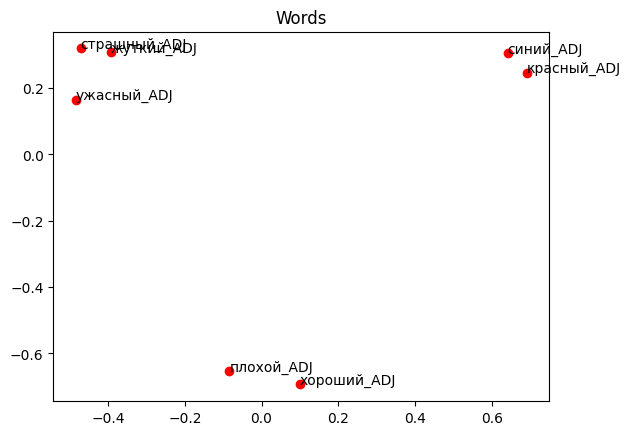

In [27]:
plt.scatter(coords[:, 0], coords[:, 1], color='red')
plt.title('Words')

for i, word in enumerate(words):
    plt.annotate(word, xy=(coords[i, 0], coords[i, 1]))
plt.show()

In [28]:
words = ['хороший_ADJ', 'плохой_ADJ', 'ужасный_ADJ','жуткий_ADJ', 'страшный_ADJ', 'злостный_ADJ', 'заядлый_ADJ', 'настоящий_ADJ', 'красный_ADJ', 'синий_ADJ']
X = model[words] #model.wv[words]

In [29]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

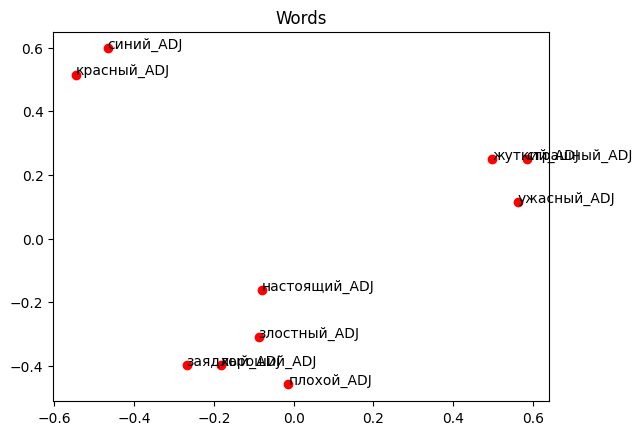

In [30]:
plt.scatter(coords[:, 0], coords[:, 1], color='red')
plt.title('Words')

for i, word in enumerate(words):
    plt.annotate(word, xy=(coords[i, 0], coords[i, 1]))
plt.show()

In [31]:
words = ['хороший_ADJ', 'плохой_ADJ', 'ужасный_ADJ','жуткий_ADJ', 'страшный_ADJ', 'злостный_ADJ', 'заядлый_ADJ']
X = model[words] #model.wv[words]

In [32]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

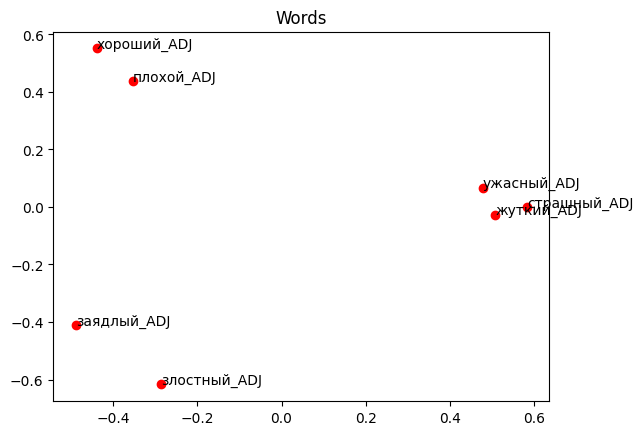

In [33]:
plt.scatter(coords[:, 0], coords[:, 1], color='red')
plt.title('Words')

for i, word in enumerate(words):
    plt.annotate(word, xy=(coords[i, 0], coords[i, 1]))
plt.show()

#### Оценка

Существуют специальные датасеты для оценки качества дистрибутивных моделей. Основных два: один измеряет точность решения задач на аналогии, а второй используется для оценки коэффициента семантической близости.

#### Word Similarity

Этот метод заключается в том, чтобы оценить, насколько представления о семантической близости слов в модели соотносятся с "представлениями" людей.

| слово 1    | слово 2    | близость |
|------------|------------|----------|
| кошка      | собака     | 0.7      |
| чашка      | кружка     | 0.9      |

Для каждой пары слов из заранее заданного датасета мы можем посчитать косинусное расстояние, и получить список таких значений близости. При этом у нас уже есть список значений близостей, сделанный людьми. Мы можем сравнить эти два списка и понять, насколько они похожи (например, посчитав корреляцию). Эта мера схожести должна говорить о том, насколько модель хорошо моделирует расстояния о слова.

#### Аналогии

Другая популярная задача для "внутренней" оценки называется задачей поиска аналогий. Как мы уже разбирали выше, с помощью простых арифметических операций мы можем модифицировать значение слова. Если заранее собрать набор слов-модификаторов, а также слов, которые мы хотим получить в результаты модификации, то на основе подсчёта количества "попаданий" в желаемое слово мы можем оценить, насколько хорошо работает модель.

В качестве слов-модификатор мы можем использовать семантические аналогии. Скажем, если у нас есть некоторое отношение "страна-столица", то для оценки модели мы можем использовать пары наподобие "Россия-Москва", "Норвегия-Осло", и т.д. Датасет будет выглядеть следующм образом:

| слово 1    | слово 2    | отношение     |
|------------|------------|---------------|
| Россия     | Москва     | страна-столица|
| Норвегия   | Осло       | страна-столица|

Рассматривая случайные две пары из этого набора, мы хотим, имея триплет (Россия, Москва, Норвегия) хотим получить слово "Осло", т.е. найти такое слово, которое будет находиться в том же отношении со словом "Норвегия", как "Россия" находится с Москвой.

[Датасеты для русского языка](https://rusvectores.org/static/testsets/) можно скачать на странице с моделями на RusVectores.